<a href="https://colab.research.google.com/github/aashi-singh-web/ML-LAB-CS/blob/main/ML_LAB_5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.metrics import precision_recall_curve, roc_curve, auc

In [2]:
data = load_breast_cancer()
X = data.data
y = data.target
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [3]:
nb_model = GaussianNB()
nb_model.fit(X_train, y_train)

GaussianNB()

In [4]:
y_pred_nb = nb_model.predict(X_test)
y_prob_nb = nb_model.predict_proba(X_test)[:,1]

In [5]:
nb_accuracy = accuracy_score(y_test, y_pred_nb)
print("Naive Bayes Accuracy:", nb_accuracy)

Naive Bayes Accuracy: 0.9736842105263158


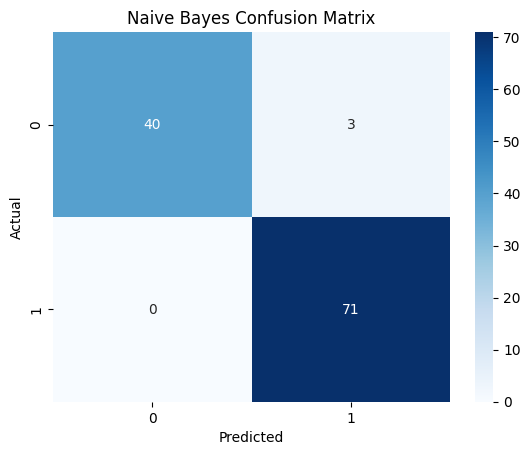

In [6]:
cm_nb = confusion_matrix(y_test, y_pred_nb)

sns.heatmap(cm_nb, annot=True, cmap="Blues", fmt='d')
plt.title("Naive Bayes Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [7]:
print("Naive Bayes Classification Report:\n")
print(classification_report(y_test, y_pred_nb))

Naive Bayes Classification Report:

              precision    recall  f1-score   support

           0       1.00      0.93      0.96        43
           1       0.96      1.00      0.98        71

    accuracy                           0.97       114
   macro avg       0.98      0.97      0.97       114
weighted avg       0.97      0.97      0.97       114



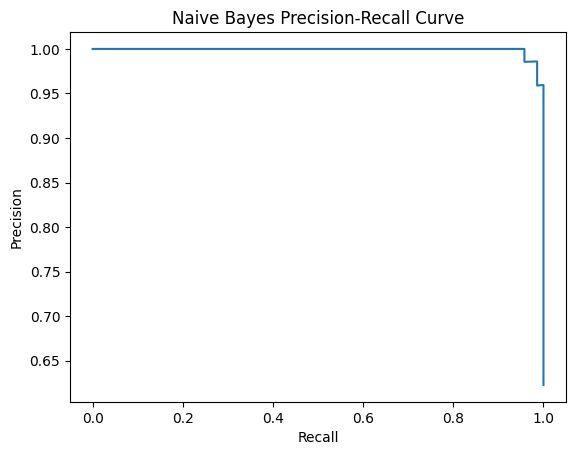

In [8]:
precision_nb, recall_nb, _ = precision_recall_curve(y_test, y_prob_nb)

plt.plot(recall_nb, precision_nb)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Naive Bayes Precision-Recall Curve")
plt.show()

In [9]:
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, y_train)

DecisionTreeClassifier(random_state=42)

In [10]:
y_pred_dt = dt_model.predict(X_test)
y_prob_dt = dt_model.predict_proba(X_test)[:,1]

In [11]:
dt_accuracy = accuracy_score(y_test, y_pred_dt)
print("Decision Tree Accuracy:", dt_accuracy)

Decision Tree Accuracy: 0.9473684210526315


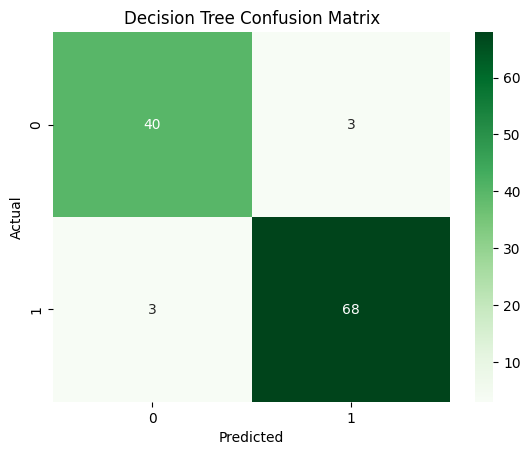

In [12]:
cm_dt = confusion_matrix(y_test, y_pred_dt)

sns.heatmap(cm_dt, annot=True, cmap="Greens", fmt='d')
plt.title("Decision Tree Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [13]:
print("Decision Tree Classification Report:\n")
print(classification_report(y_test, y_pred_dt))

Decision Tree Classification Report:

              precision    recall  f1-score   support

           0       0.93      0.93      0.93        43
           1       0.96      0.96      0.96        71

    accuracy                           0.95       114
   macro avg       0.94      0.94      0.94       114
weighted avg       0.95      0.95      0.95       114



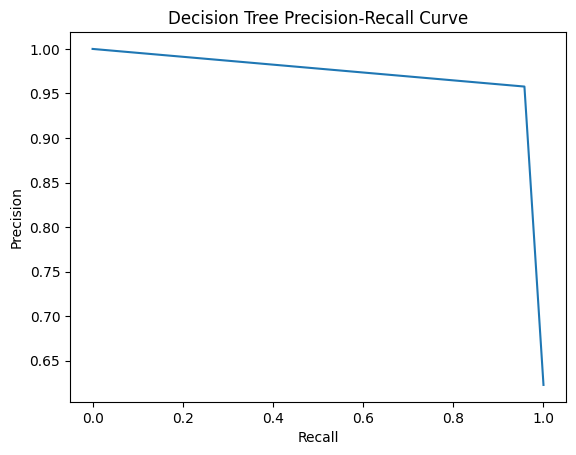

In [14]:
precision_dt, recall_dt, _ = precision_recall_curve(y_test, y_prob_dt)

plt.plot(recall_dt, precision_dt)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Decision Tree Precision-Recall Curve")
plt.show()

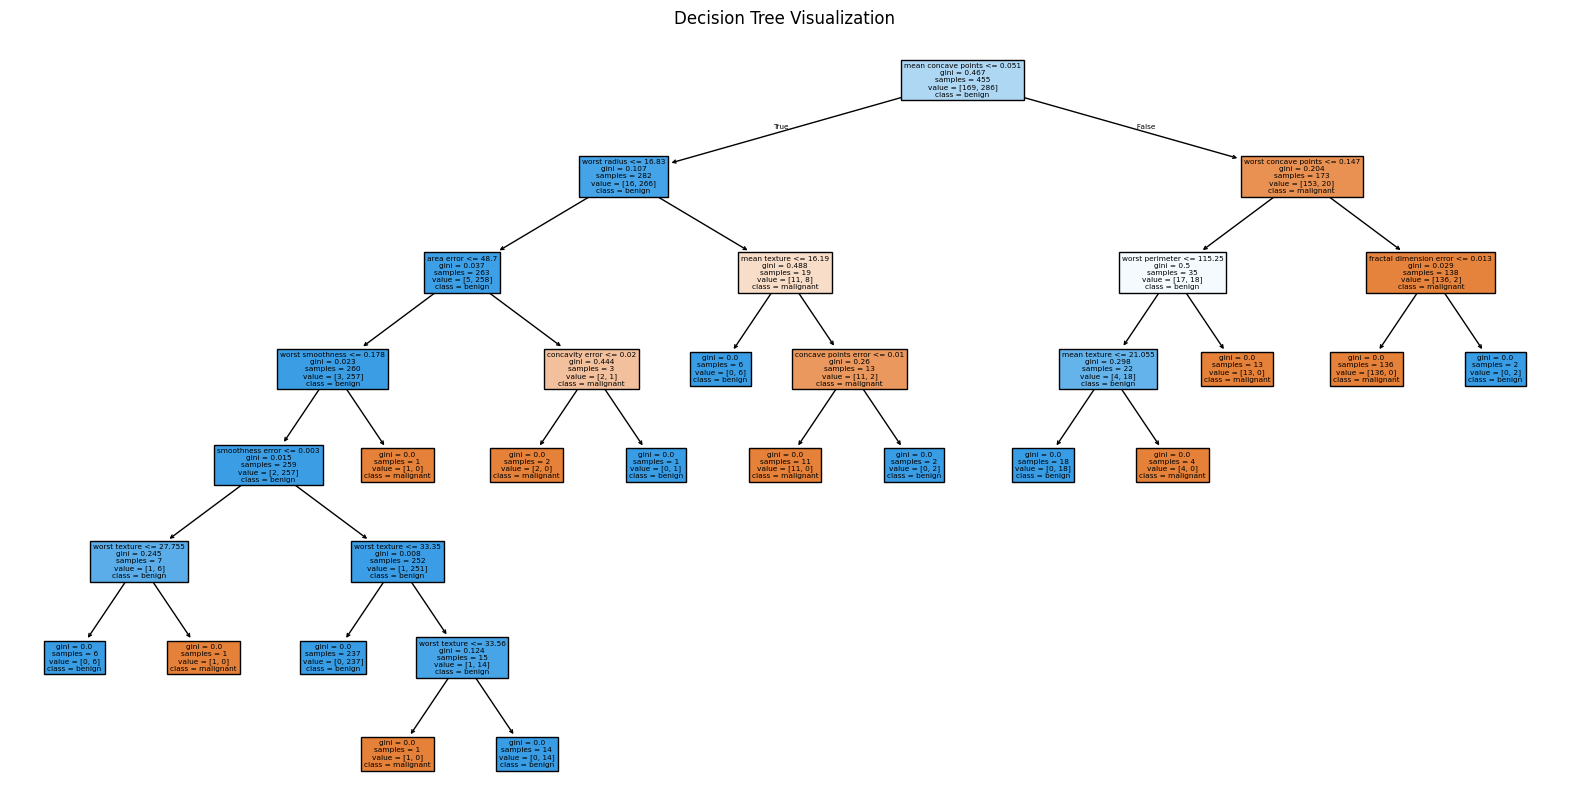

In [15]:
plt.figure(figsize=(20,10))

plot_tree(
    dt_model,
    feature_names=data.feature_names,
    class_names=data.target_names,
    filled=True
)

plt.title("Decision Tree Visualization")
plt.show()

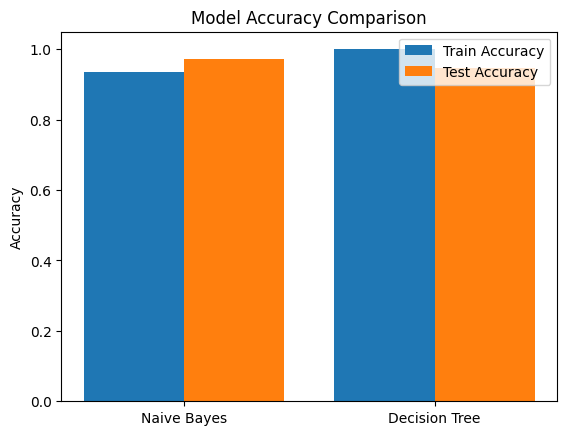

In [16]:
train_acc_nb = nb_model.score(X_train, y_train)
test_acc_nb = nb_model.score(X_test, y_test)

train_acc_dt = dt_model.score(X_train, y_train)
test_acc_dt = dt_model.score(X_test, y_test)

models = ['Naive Bayes','Decision Tree']
train_scores = [train_acc_nb, train_acc_dt]
test_scores = [test_acc_nb, test_acc_dt]

x = np.arange(len(models))

plt.bar(x-0.2, train_scores, width=0.4, label='Train Accuracy')
plt.bar(x+0.2, test_scores, width=0.4, label='Test Accuracy')

plt.xticks(x, models)
plt.ylabel("Accuracy")
plt.title("Model Accuracy Comparison")
plt.legend()
plt.show()

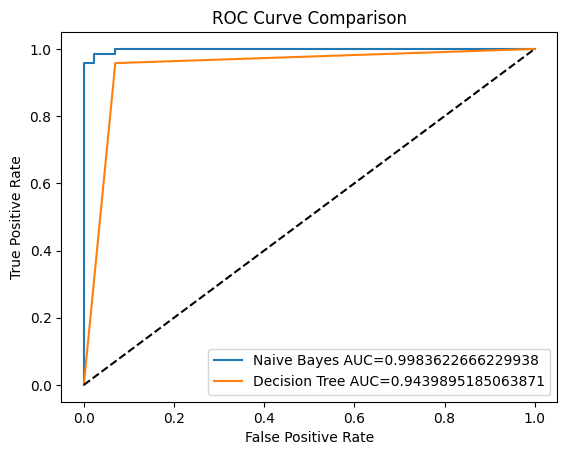

In [17]:
fpr_nb, tpr_nb, _ = roc_curve(y_test, y_prob_nb)
fpr_dt, tpr_dt, _ = roc_curve(y_test, y_prob_dt)

roc_auc_nb = auc(fpr_nb, tpr_nb)
roc_auc_dt = auc(fpr_dt, tpr_dt)

plt.plot(fpr_nb, tpr_nb, label="Naive Bayes AUC="+str(roc_auc_nb))
plt.plot(fpr_dt, tpr_dt, label="Decision Tree AUC="+str(roc_auc_dt))

plt.plot([0,1],[0,1],'k--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.show()

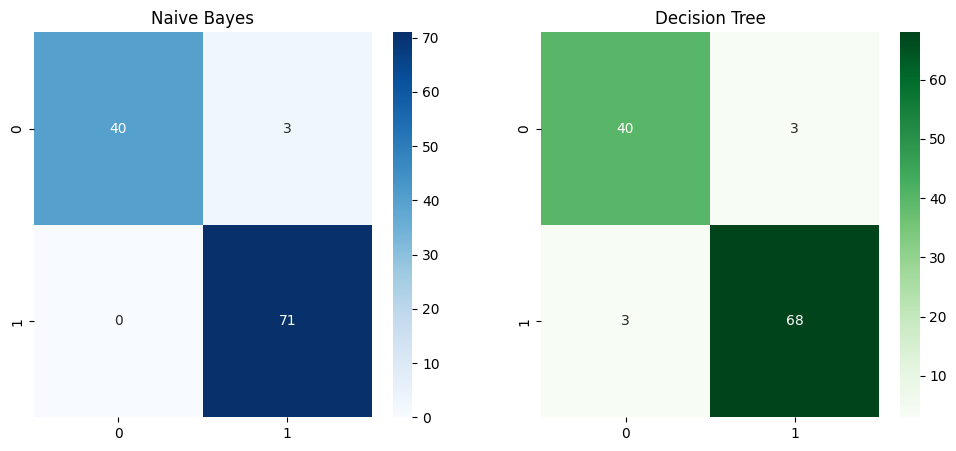

In [18]:
fig, ax = plt.subplots(1,2, figsize=(12,5))

sns.heatmap(cm_nb, annot=True, fmt='d', cmap="Blues", ax=ax[0])
ax[0].set_title("Naive Bayes")

sns.heatmap(cm_dt, annot=True, fmt='d', cmap="Greens", ax=ax[1])
ax[1].set_title("Decision Tree")

plt.show()